In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os

In [2]:
df = pd.read_csv("C:/Users/lerak/OneDrive/Desktop/bank_churn_analysis/data/raw/Bank_Customer_Churn_Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
features = ['age', 'balance', 'credit_score', 'tenure', 'products_number', 'estimated_salary']

X_cluster = df[features].copy()

print(X_cluster.describe())

                age        balance  credit_score        tenure  \
count  10000.000000   10000.000000  10000.000000  10000.000000   
mean      38.921800   76485.889288    650.528800      5.012800   
std       10.487806   62397.405202     96.653299      2.892174   
min       18.000000       0.000000    350.000000      0.000000   
25%       32.000000       0.000000    584.000000      3.000000   
50%       37.000000   97198.540000    652.000000      5.000000   
75%       44.000000  127644.240000    718.000000      7.000000   
max       92.000000  250898.090000    850.000000     10.000000   

       products_number  estimated_salary  
count     10000.000000      10000.000000  
mean          1.530200     100090.239881  
std           0.581654      57510.492818  
min           1.000000         11.580000  
25%           1.000000      51002.110000  
50%           1.000000     100193.915000  
75%           2.000000     149388.247500  
max           4.000000     199992.480000  


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled.head()

,age,balance,credit_score,tenure,products_number,estimated_salary
0,0.293517,-1.225848,-0.326221,-1.041760,-0.911583,0.021886
1,0.198164,0.117350,-0.440036,-1.387538,-0.911583,0.216534
2,0.293517,1.333053,-1.536794,1.032908,2.527057,0.240687
3,0.007457,-1.225848,0.501521,-1.387538,0.807737,-0.108918
4,0.388871,0.785728,2.063884,-1.041760,-0.911583,-0.365276


Признаки приведены к единому масштабу через StandardScaler, так как K-Means чувствителен к разнице в масштабах. Без масштабирования признак с большими значениями доминировал бы над остальными.

In [ ]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linewidth=2)
plt.title('Метод локтя для выбора числа кластеров')
plt.xlabel('Число кластеров')
plt.ylabel('Инерция')
plt.grid(True)
plt.savefig('../images/elbow_method.png', dpi=100, bbox_inches='tight')
plt.show()

Метод локтя используется для выбора оптимального числа кластеров. Инерция резко падает до определённого значения, после чего снижение замедляется. Точка перелома показывает оптимальное число кластеров.

In [6]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'].value_counts())

Cluster
2    3084
3    2853
1    2673
0    1390
Name: count, dtype: int64


Выбрано 4 кластера на основе метода локтя. Каждому клиенту присвоен номер кластера.

In [7]:
cluster_profile = df.groupby('Cluster')[features].mean().round(2)

print(cluster_profile)

           age    balance  credit_score  tenure  products_number  \
Cluster                                                            
0        58.01   78417.19        644.38    4.83             1.37   
1        36.08  111720.84        644.88    7.75             1.27   
2        35.86   10867.34        650.25    5.13             2.04   
3        35.59  113464.54        659.12    2.40             1.30   

         estimated_salary  
Cluster                    
0                95406.83  
1               102528.29  
2                99601.98  
3               100615.59  


## 6. Профиль кластеров

Кластер 0 объединяет пожилых клиентов со средним возрастом 58 лет, средним балансом 78 417 и стажем 4.8 года. Это самая проблемная группа с оттоком 45%. Кластер 1 включает клиентов 36 лет с высоким балансом 111 721 и самым большим стажем 7.8 лет. Это лояльные клиенты с деньгами, но у них только 1.27 продукта. Кластер 2 объединяет клиентов 36 лет с самым низким балансом 10 867 и самым высоким количеством продуктов 2.04. Отток здесь самый низкий, 12%. Кластер 3 включает клиентов 36 лет с высоким балансом 113 465 и самым маленьким стажем 2.4 года. Это новые клиенты с деньгами, которые ещё не привязались к банку.

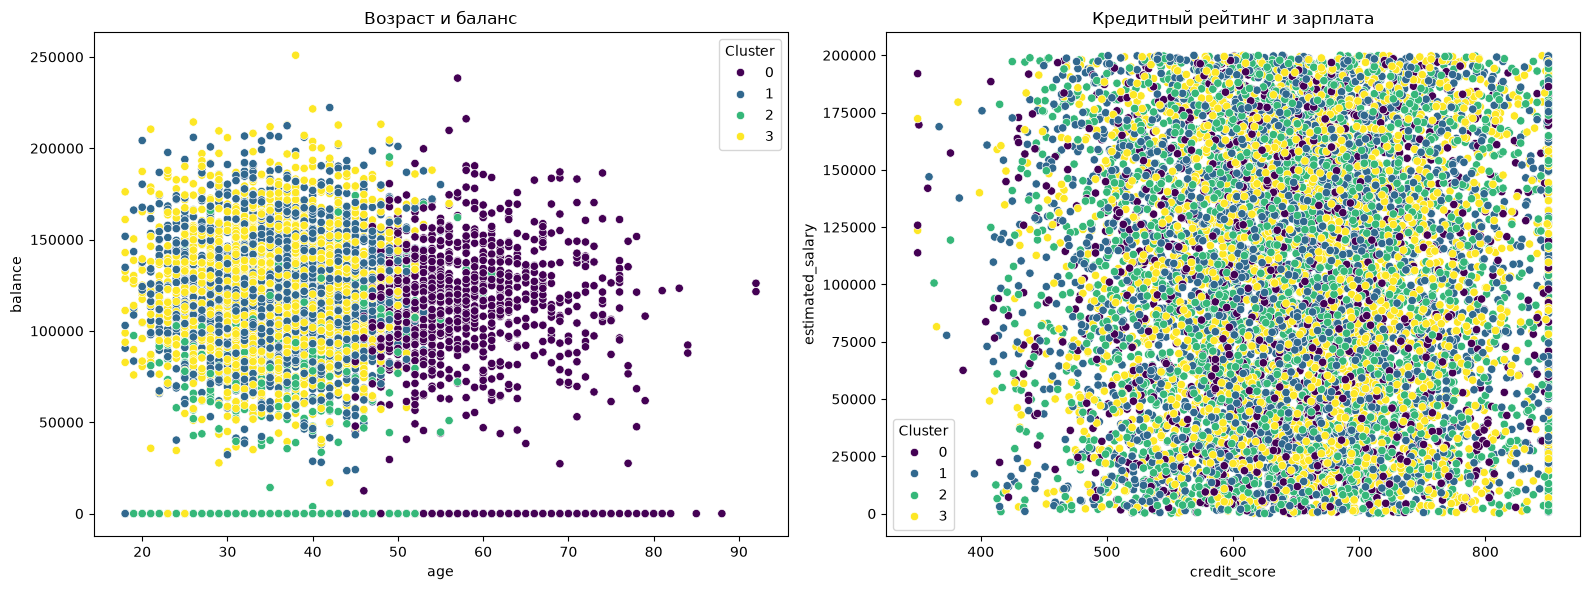

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='age', y='balance', hue='Cluster', palette='viridis', ax=axes[0])
axes[0].set_title('Возраст и баланс')

sns.scatterplot(data=df, x='credit_score', y='estimated_salary', hue='Cluster', palette='viridis', ax=axes[1])
axes[1].set_title('Кредитный рейтинг и зарплата')

plt.tight_layout()
plt.savefig('../images/clusters_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

Отток по кластерам:
         Доля оттока  Количество клиентов
Cluster                                  
0             0.4504                 1390
1             0.1927                 2673
2             0.1206                 3084
3             0.1837                 2853


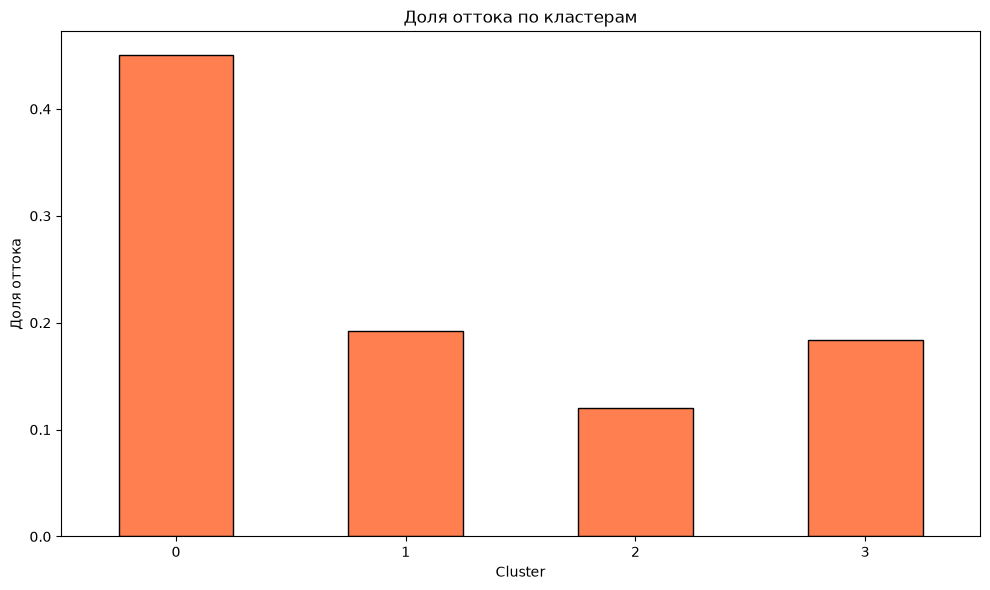

In [9]:
churn_by_cluster = df.groupby('Cluster')['churn'].agg(['mean', 'count']).round(4)
churn_by_cluster.columns = ['Доля оттока', 'Количество клиентов']
print("Отток по кластерам:")
print(churn_by_cluster)

plt.figure(figsize=(10, 6))
churn_by_cluster['Доля оттока'].plot(kind='bar', color='coral', edgecolor='black')
plt.title('Доля оттока по кластерам')
plt.ylabel('Доля оттока')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/churn_by_cluster.png', dpi=100, bbox_inches='tight')
plt.show()

Кластер 0 показывает наибольшую долю оттока 45.04%. Это в 3.7 раза выше, чем в кластере 2, где отток составляет 12.06%. Кластеры 1 и 3 показывают средний уровень оттока около 19%. Кластер 2 можно считать наиболее лояльным, здесь самая низкая доля оттока и наибольшее количество клиентов. Кластер 0 требует особого внимания. Необходимо понять, какие характеристики объединяют этих клиентов, чтобы разработать программу удержания.

In [10]:
df.to_csv('../data/processed/bank_churn_clusters.csv', index=False)